# CREAM on Alpha-Recovered Graph

**Experiment 5 — Alpha graph recovery**

Alpha matrix learned in Exp4 is thresholded → binary graph → feed into standard single CREAM.

## Pipeline
```
Exp4: mCREAM Ensemble trains on noisy consensus graphs
    → shared α[K,K] learned: α[i,j] = importance of edge i→j
    → mean α across 5 seeds
    → threshold at t (e.g. 0.5): keep edge if α ≥ t
    → binary recovered graph [K,K]
    → CREAM trains on this recovered graph
```

## Three comparisons per noise level
| Model | Graph used | Expected |
|---|---|---|
| CREAM GT | Ground truth DAG | Upper bound |
| CREAM noisy | Expert_0 noisy graph | Lower bound |
| CREAM alpha | Alpha-recovered binary graph | Does alpha recover GT? |

## Prerequisites
```bash
# Step 1: Run Exp4 to get alpha matrices
# Step 2: Generate recovered graphs + configs
python generate_alpha_recovered_graphs.py --dataset cfmnist --threshold 0.5
# Step 3: Run CREAM on recovered graphs
bash server_scripts/cream_experiment/submit_cream_alpha.sh
```

In [1]:
import pandas as pd, numpy as np, re, torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from matplotlib.colors import LinearSegmentedColormap
import warnings; warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

LEVEL_COLOR  = {'low': '#3498db', 'medium': '#e67e22', 'high': '#e74c3c'}
LEVEL_NUM    = {'low': 0.15, 'medium': 0.25, 'high': 0.50}
LEVELS       = ['low', 'medium', 'high']

EXPERIMENTS_ROOT = Path('/home/dani00003/mCREAM/experiments')
DATA_ROOT        = Path('/home/dani00003/mCREAM/data')

DATASETS = {
    'cfmnist': {
        'exp_model':    'Standard_FashionMNIST',
        'dataset_name': 'Complete_Concept_FMNIST',
        'gt_dag':       DATA_ROOT / 'FashionMNIST/Complete_Concept_FMNIST_DAG.csv',
        'alpha_dag_dir': DATA_ROOT / 'FashionMNIST/alpha_recovered_dags',
        'noisy_dag_dir': DATA_ROOT / 'FashionMNIST/noisy_dags',
        'num_concepts': 11,
        'num_classes':  10,
    },
    'celeba': {
        'exp_model':    'Standard_CelebA',
        'dataset_name': 'CelebA',
        'gt_dag':       DATA_ROOT / 'CelebA/final_DAG_unfair.csv',
        'alpha_dag_dir': DATA_ROOT / 'CelebA/alpha_recovered_dags',
        'noisy_dag_dir': DATA_ROOT / 'CelebA/noisy_dags',
        'num_concepts': 7,
        'num_classes':  1,
    },
    'cub': {
        'exp_model':    'Standard_CUB',
        'dataset_name': 'CUB',
        'gt_dag':       DATA_ROOT / 'CUB/CUB_DAG_only_Gc.csv',
        'alpha_dag_dir': DATA_ROOT / 'CUB/alpha_recovered_dags',
        'noisy_dag_dir': DATA_ROOT / 'CUB/noisy_dags',
        'num_concepts': 112,
        'num_classes':  200,
    },
}

THRESHOLD = 0.5   # alpha binarisation threshold

# Grey → green colormap for alpha
CMAP_GG = LinearSegmentedColormap.from_list('grey_green', ['#e8e8e8','#c8e6c9','#66bb6a','#2e7d32'])

print(f'Root exists: {EXPERIMENTS_ROOT.exists()}')

Root exists: True


---
# Section 1 — Alpha Matrix: Mean, Binary, Comparison to GT

Load learned alpha from Exp4, show:
- Mean α across seeds (continuous, grey→green)
- Binary α after threshold (0 or 1)
- Side-by-side vs GT graph
- Precision/Recall of recovered edges vs GT

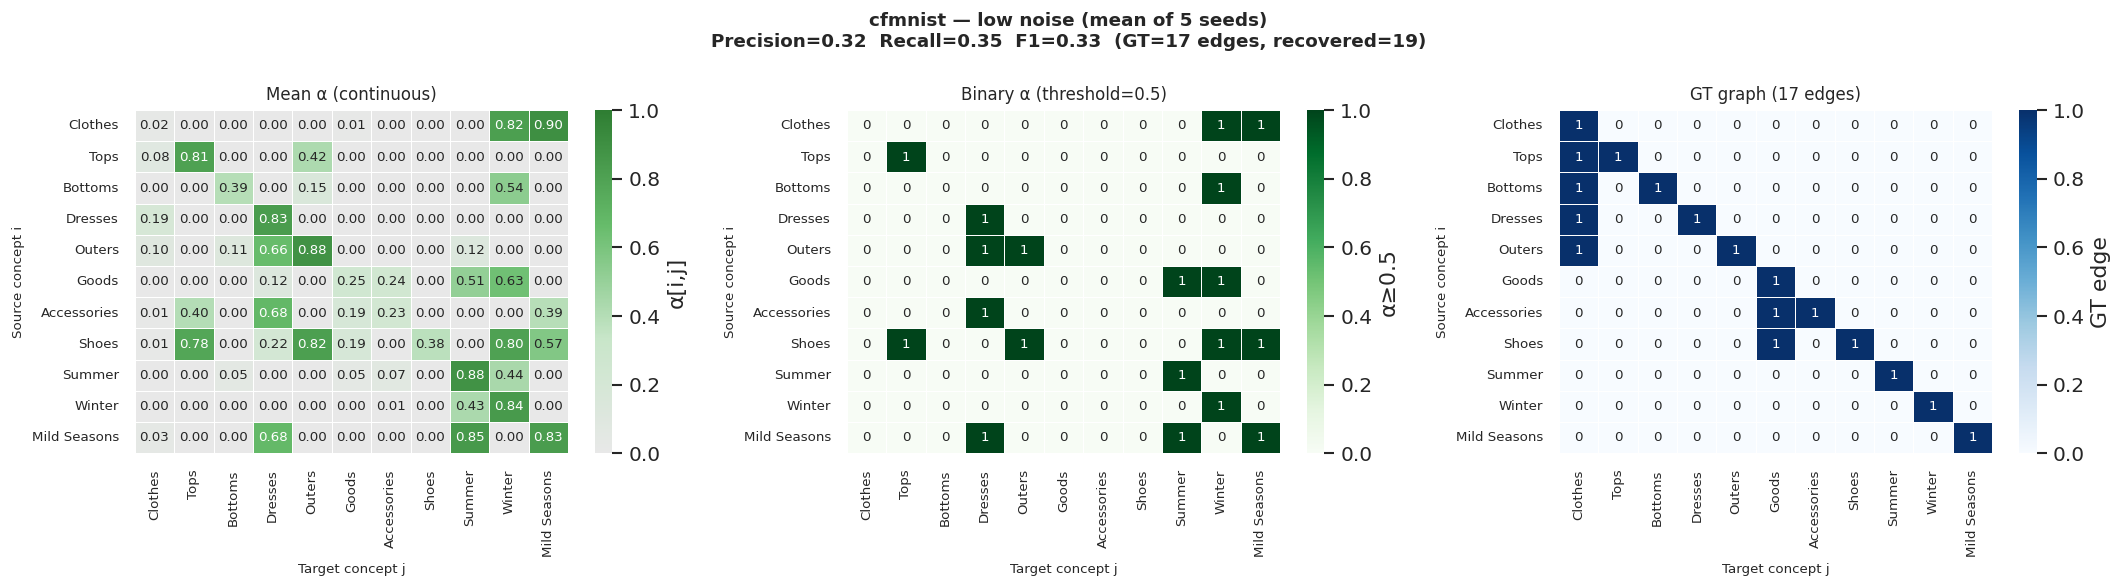

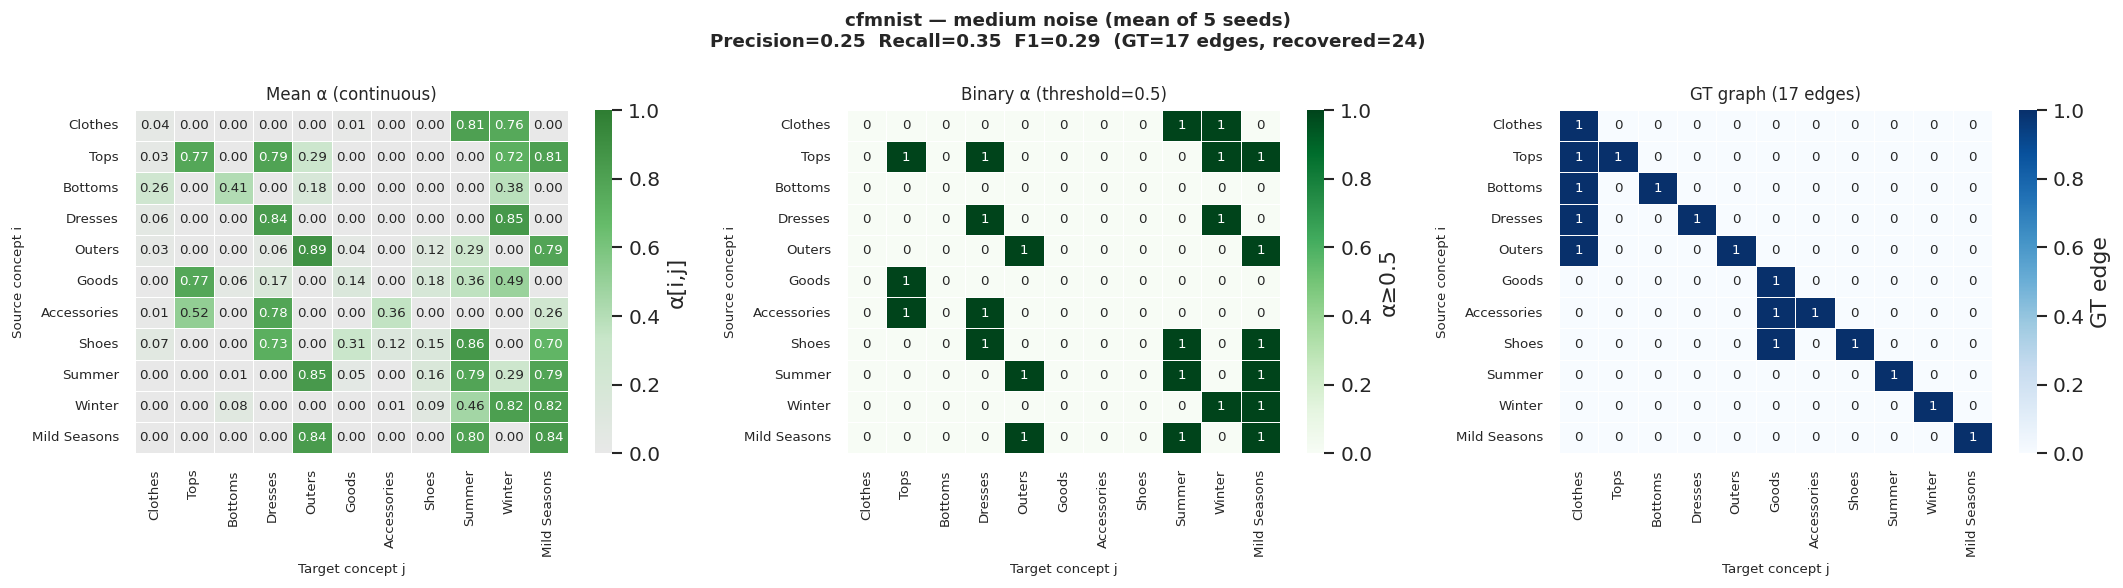

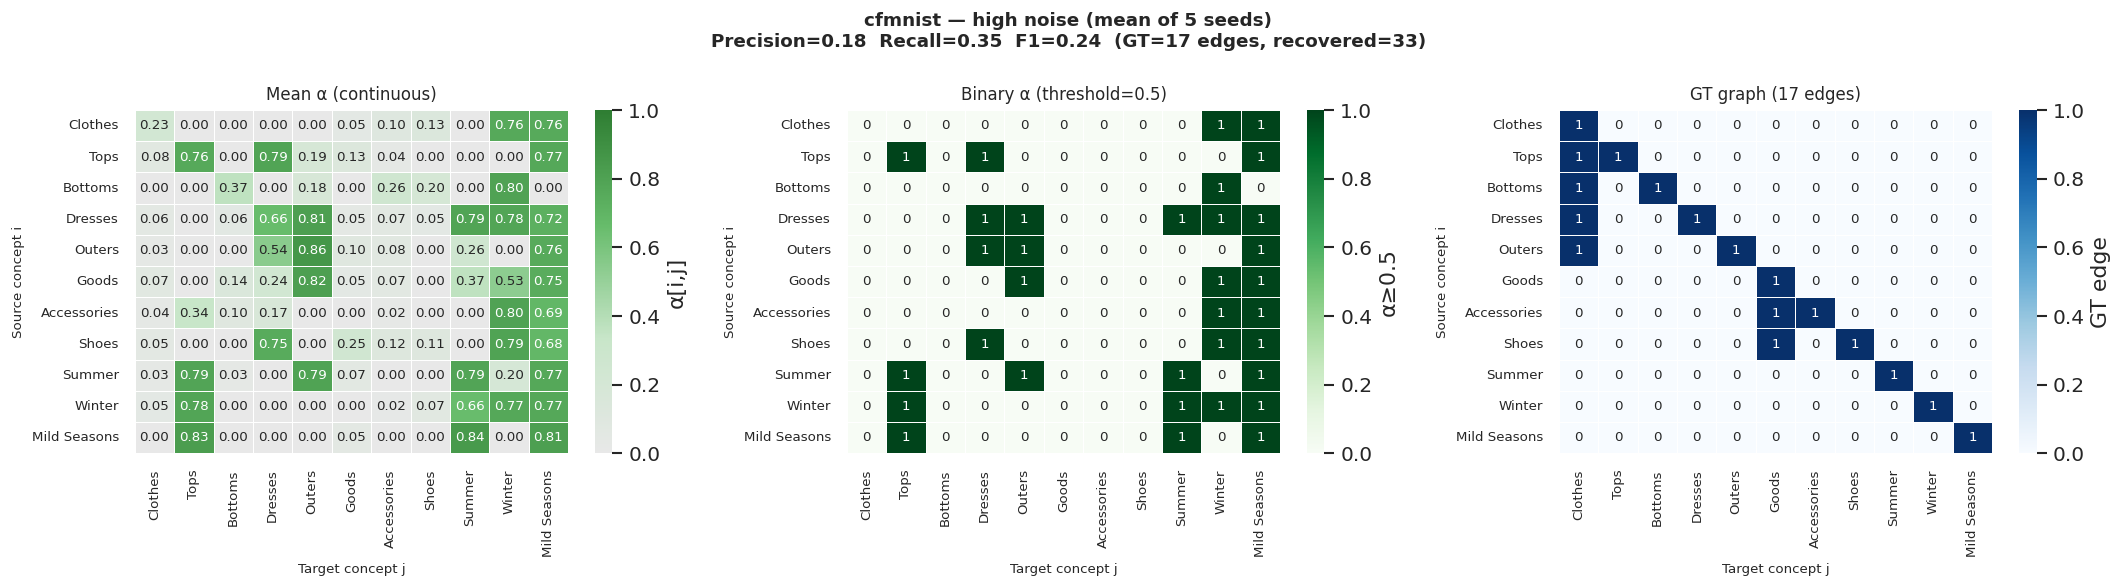

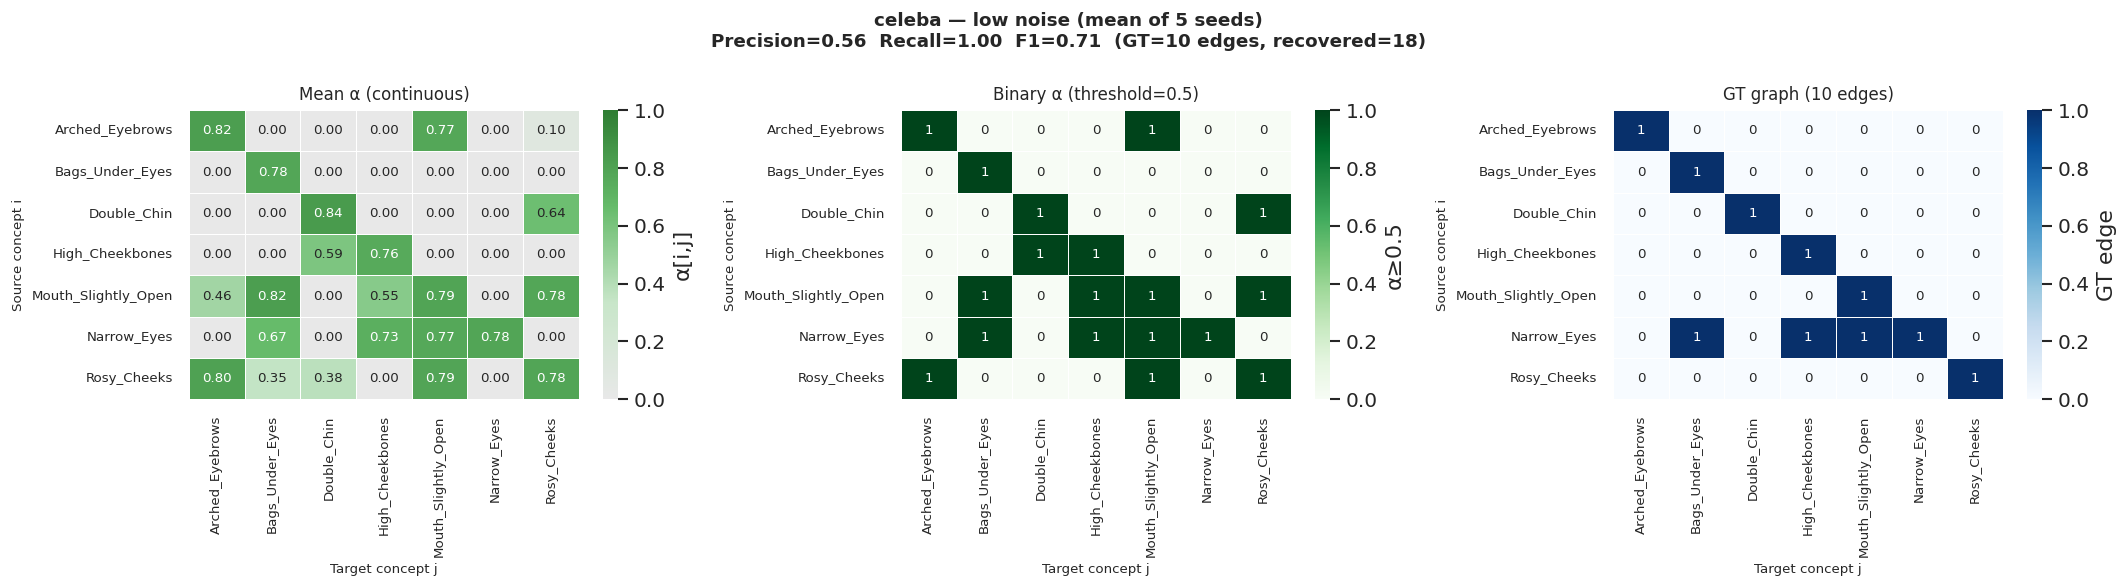

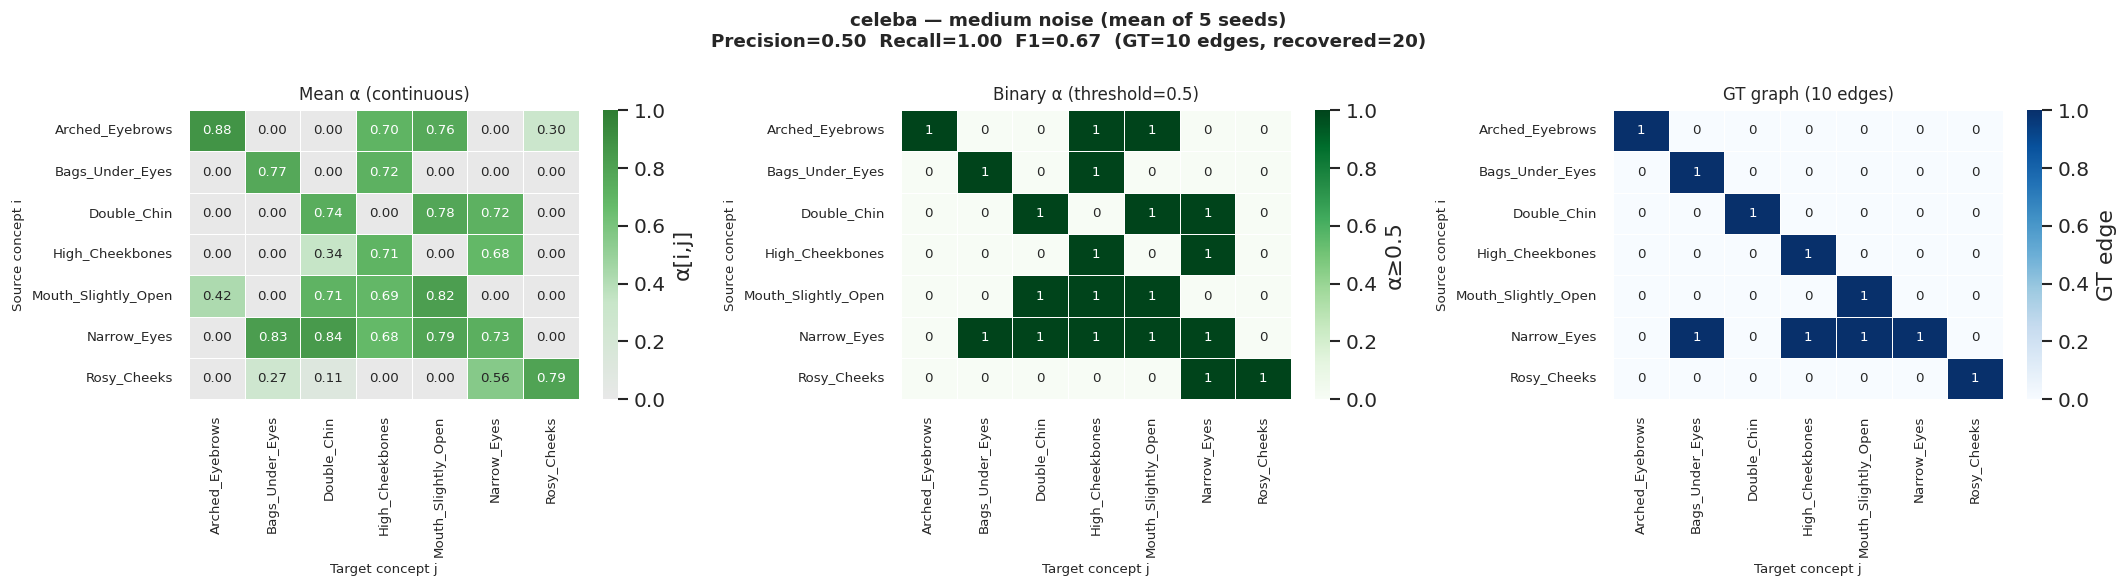

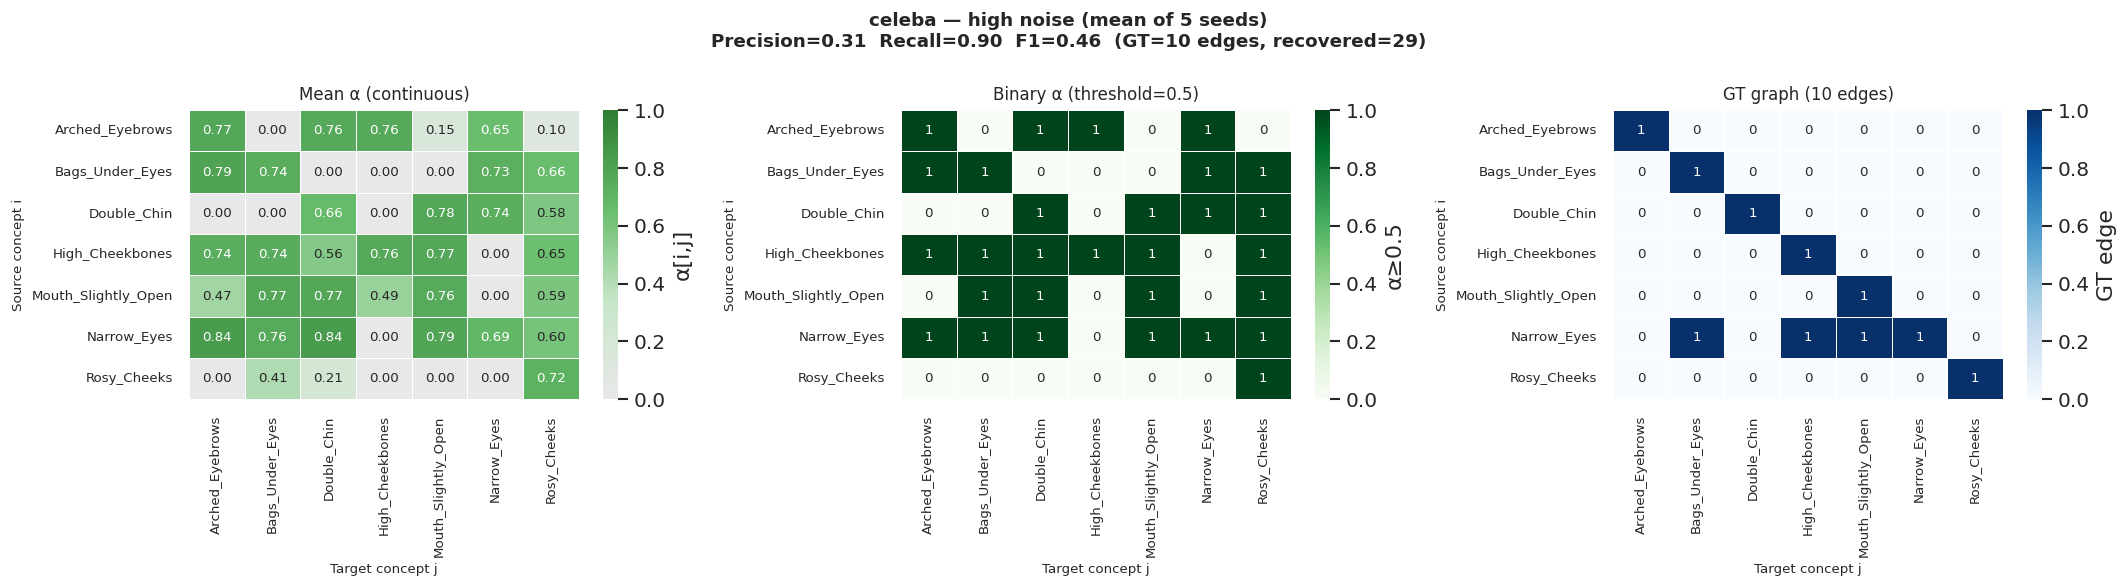

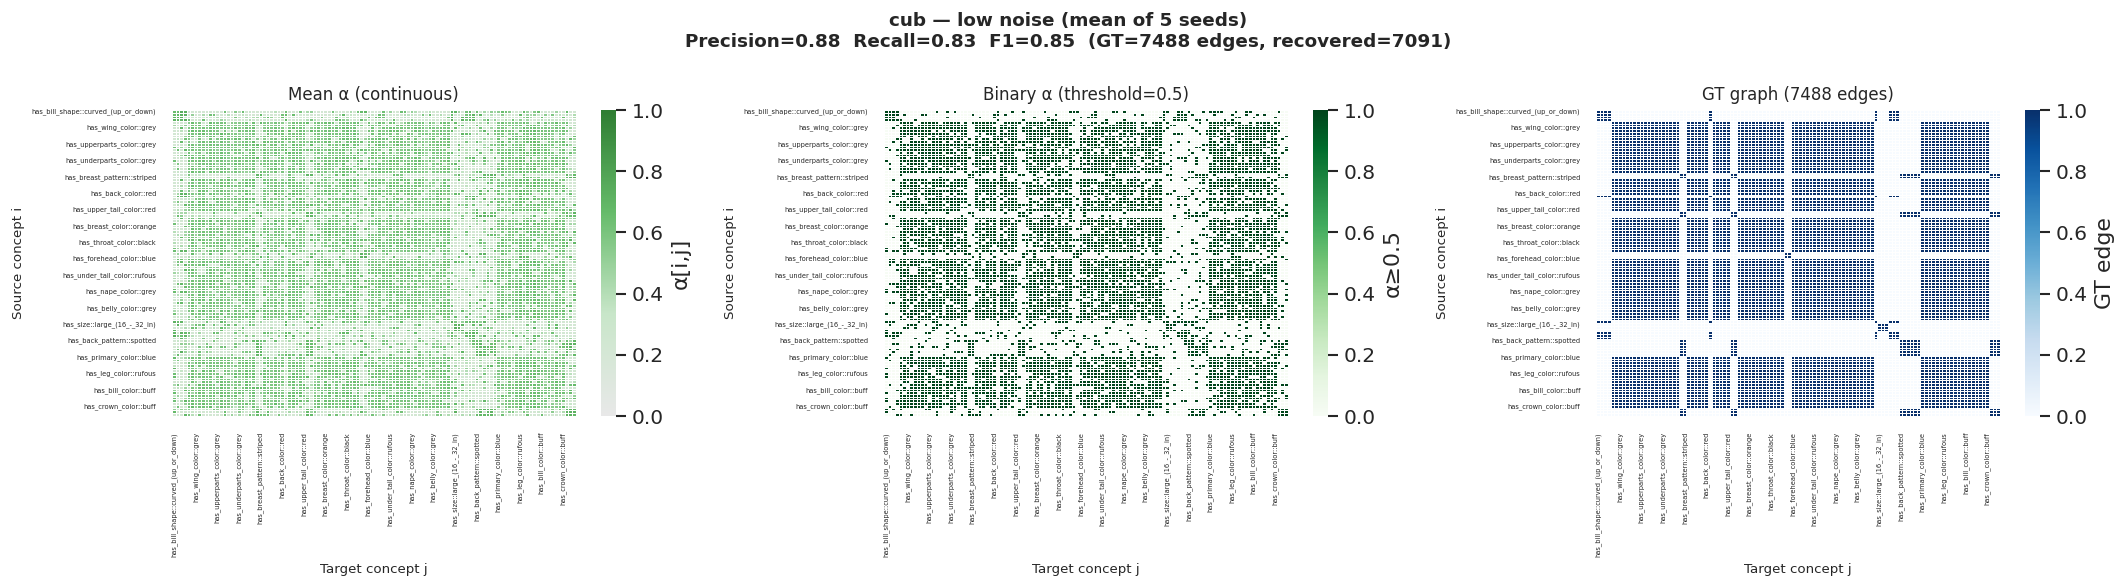

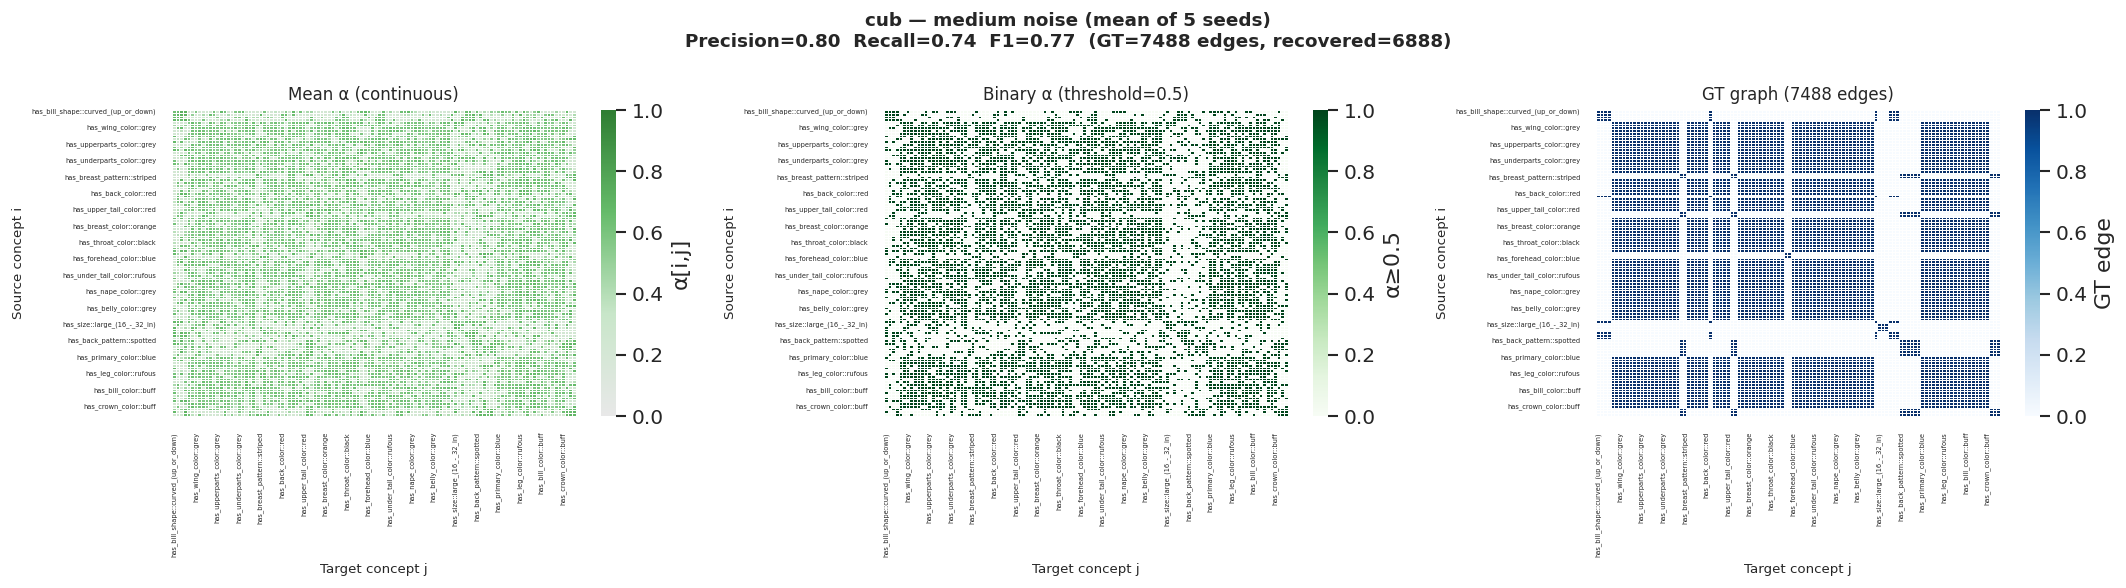

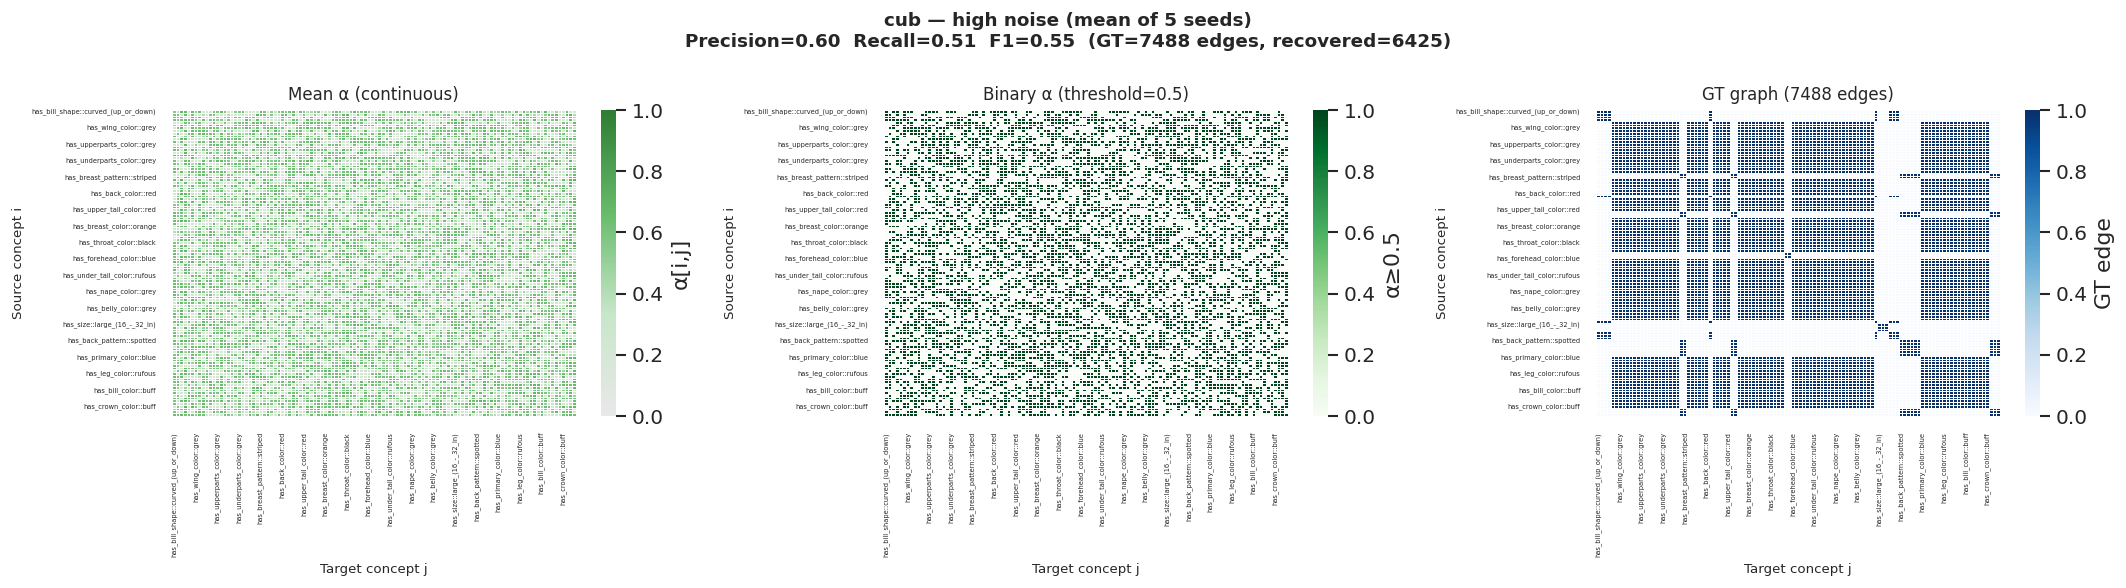


=== Graph Recovery Summary ===


precision  recall     f1  n_recovered  n_gt
dataset level                                              
cfmnist low         0.316   0.353  0.333           19    17
        medium      0.250   0.353  0.293           24    17
        high        0.182   0.353  0.240           33    17
celeba  low         0.556   1.000  0.714           18    10
        medium      0.500   1.000  0.667           20    10
        high        0.310   0.900  0.462           29    10
cub     low         0.876   0.829  0.852         7091  7488
        medium      0.805   0.740  0.771         6888  7488
        high        0.596   0.511  0.550         6425  7488

In [2]:
def load_alpha_for_level(ds_name, level, ens_root=EXPERIMENTS_ROOT):
    """Load all alpha_prob_seed*.csv for one dataset/level, return mean DataFrame."""
    cfg = DATASETS[ds_name]
    exp_dir = ens_root / cfg['dataset_name'] / 'train_cbm' / 'mCREAM_GraphEnsemble'
    exp_name = f'graph_ensemble_consensus_{level}'
    consensus_dir = exp_dir / exp_name
    if not consensus_dir.exists():
        return None, None
    alphas = []
    concept_names = None
    for seed_dir in sorted(consensus_dir.glob('seed_*/lightning_logs/version_*')):
        for alpha_f in sorted(seed_dir.glob('alpha_prob_seed*.csv')):
            df = pd.read_csv(alpha_f, index_col=0)
            alphas.append(df.values)
            if concept_names is None:
                concept_names = list(df.index)
    if not alphas:
        return None, None
    mean_alpha = np.stack(alphas).mean(axis=0)
    return pd.DataFrame(mean_alpha, index=concept_names, columns=concept_names), len(alphas)


def plot_alpha_vs_gt(alpha_df, gt_dag_path, num_concepts, threshold, title):
    """Show mean alpha, binary alpha, and GT graph side by side."""
    gt_df  = pd.read_csv(gt_dag_path, index_col=0)
    gt_u2c = gt_df.values.astype(bool)[:num_concepts, :num_concepts]
    alpha  = alpha_df.values
    binary = (alpha >= threshold).astype(int)

    # Precision / recall
    n_gt     = gt_u2c.sum()
    n_rec    = binary.sum()
    n_correct = (binary.astype(bool) & gt_u2c).sum()
    prec  = n_correct / max(n_rec, 1)
    rec   = n_correct / max(n_gt, 1)
    f1    = 2*prec*rec / max(prec+rec, 1e-9)

    concept_names = list(alpha_df.index)
    tick_fs = max(4, 8 - num_concepts // 20)  # smaller font for large K

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{title}\nPrecision={prec:.2f}  Recall={rec:.2f}  F1={f1:.2f}  '
                 f'(GT={n_gt} edges, recovered={n_rec})',
                 fontsize=11, fontweight='bold')

    # Mean alpha
    sns.heatmap(alpha_df, ax=axes[0], vmin=0, vmax=1, cmap=CMAP_GG,
                annot=(num_concepts <= 15), fmt='.2f', linewidths=0.3,
                annot_kws={'size': tick_fs}, cbar_kws={'label': 'α[i,j]'})
    axes[0].set_title('Mean α (continuous)', fontsize=10)
    axes[0].tick_params(labelsize=tick_fs)

    # Binary alpha
    binary_df = pd.DataFrame(binary, index=concept_names, columns=concept_names)
    sns.heatmap(binary_df, ax=axes[1], vmin=0, vmax=1, cmap='Greens',
                annot=(num_concepts <= 15), fmt='d', linewidths=0.3,
                annot_kws={'size': tick_fs}, cbar_kws={'label': f'α≥{threshold}'})
    axes[1].set_title(f'Binary α (threshold={threshold})', fontsize=10)
    axes[1].tick_params(labelsize=tick_fs)

    # GT graph
    gt_small = pd.DataFrame(gt_u2c.astype(int), index=concept_names, columns=concept_names)
    sns.heatmap(gt_small, ax=axes[2], vmin=0, vmax=1, cmap='Blues',
                annot=(num_concepts <= 15), fmt='d', linewidths=0.3,
                annot_kws={'size': tick_fs}, cbar_kws={'label': 'GT edge'})
    axes[2].set_title(f'GT graph ({n_gt} edges)', fontsize=10)
    axes[2].tick_params(labelsize=tick_fs)

    for ax in axes:
        ax.set_xlabel('Target concept j', fontsize=8)
        ax.set_ylabel('Source concept i', fontsize=8)
    plt.tight_layout()
    plt.show()
    return {'precision': prec, 'recall': rec, 'f1': f1, 'n_recovered': n_rec, 'n_gt': n_gt}


# ── Run for each dataset and level ───────────────────────────────────────────
graph_recovery_stats = []

for ds_name, cfg in DATASETS.items():
    gt_path = cfg['gt_dag']
    if not gt_path.exists(): print(f'GT DAG not found: {gt_path}'); continue
    K = cfg['num_concepts']

    for level in LEVELS:
        alpha_df, n_seeds = load_alpha_for_level(ds_name, level)
        if alpha_df is None:
            print(f'[SKIP] {ds_name}/{level} — no alpha CSVs')
            continue
        stats = plot_alpha_vs_gt(
            alpha_df, gt_path, K, THRESHOLD,
            f'{ds_name} — {level} noise (mean of {n_seeds} seeds)'
        )
        stats.update({'dataset': ds_name, 'level': level})
        graph_recovery_stats.append(stats)

if graph_recovery_stats:
    print('\n=== Graph Recovery Summary ===')
    display(pd.DataFrame(graph_recovery_stats).set_index(['dataset','level']).round(3))

---
# Section 2 — CREAM Results: GT vs Noisy vs Alpha-Recovered

Load test metrics for all three CREAM variants and compare directly.

In [ ]:
def load_cream_results(exp_root, dataset_name, model_name, exp_names):
    """Load metrics CSV for a list of experiment names. Returns dict: exp_name → DataFrame."""
    results = {}
    base = exp_root / dataset_name / 'train_cbm' / model_name
    for exp_name in exp_names:
        exp_dir = base / exp_name
        if not exp_dir.exists(): continue
        rows = []
        for seed_dir in sorted(exp_dir.glob('seed_*/lightning_logs/version_*')):
            seed = int(seed_dir.parent.parent.name.split('_')[1])
            for csv_f in sorted(seed_dir.glob('*.csv')):
                if any(x in csv_f.name for x in ['perc_','_set_','intervention','exogenous','alpha']):
                    continue
                try:
                    df = pd.read_csv(csv_f); df['seed'] = seed; rows.append(df)
                except: pass
        # also check last_metrics/ (simple_main.py path)
        lm = exp_dir / 'last_metrics'
        if lm.exists():
            for csv_f in sorted(lm.glob('*.csv')):
                try:
                    df = pd.read_csv(csv_f); rows.append(df)
                except: pass
        if rows:
            results[exp_name] = pd.concat(rows, ignore_index=True)
    return results


def load_interventions_cream(exp_root, dataset_name, model_name, exp_names):
    """Load intervention_results.csv for given experiments."""
    rows = []
    base = exp_root / dataset_name / 'train_cbm' / model_name
    for exp_name in exp_names:
        for csv_f in (base / exp_name).rglob('intervention_results.csv'):
            try:
                df = pd.read_csv(csv_f)
                seed = None
                for p in csv_f.parts:
                    if p.startswith('seed_'): seed = int(p.split('_')[1])
                df['exp_name'] = exp_name; df['seed'] = seed
                rows.append(df)
            except: pass
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame()


# ── Load results for each dataset ────────────────────────────────────────────
all_results   = {}   # key: (ds_name, variant, level)
all_interv    = {}

for ds_name, cfg in DATASETS.items():
    model = cfg['exp_model']
    ds    = cfg['dataset_name']

    # GT CREAM
    gt_res = load_cream_results(EXPERIMENTS_ROOT, ds, model, ['CREAM_best_cfmnist', 'CREAM_best_celeba', 'CREAM_best_cub'])
    if gt_res:
        all_results[(ds_name, 'GT', '—')] = list(gt_res.values())[0]

    for level in LEVELS:
        # CREAM on noisy (expert_0)
        noisy_res = load_cream_results(EXPERIMENTS_ROOT, ds, model, [f'cream_noisy_{level}', f'cream_noisy_addition_{level}'])
        if noisy_res:
            all_results[(ds_name, 'noisy', level)] = list(noisy_res.values())[0]

        # CREAM on alpha-recovered graph
        alpha_res = load_cream_results(EXPERIMENTS_ROOT, ds, model, [f'cream_alpha_{level}'])
        if alpha_res:
            all_results[(ds_name, 'alpha', level)] = list(alpha_res.values())[0]

        # Interventions for alpha
        iv = load_interventions_cream(EXPERIMENTS_ROOT, ds, model, [f'cream_alpha_{level}'])
        if len(iv): all_interv[(ds_name, level)] = iv

print(f'Loaded {len(all_results)} result sets')
for k in all_results: print(f'  {k}')

Loaded 0 result sets


In [4]:
# ── Summary table: GT vs noisy vs alpha per dataset ──────────────────────────
KEY = ['test_task_accuracy', 'test_concept_accuracy', 'CCI']

for ds_name in DATASETS:
    rows = []
    # GT
    key = (ds_name, 'GT', '—')
    if key in all_results:
        grp = all_results[key]
        r = {'variant': 'GT CREAM', 'level': '—'}
        for m in KEY:
            r[m] = f"{grp[m].mean():.4f} ± {grp[m].std():.4f}" if m in grp.columns else '—'
        rows.append(r)

    for level in LEVELS:
        for variant, label in [('noisy','CREAM noisy'), ('alpha','CREAM alpha')]:
            key = (ds_name, variant, level)
            if key not in all_results: continue
            grp = all_results[key]
            r = {'variant': label, 'level': level}
            for m in KEY:
                r[m] = f"{grp[m].mean():.4f} ± {grp[m].std():.4f}" if m in grp.columns else '—'
            rows.append(r)

    if rows:
        print(f'\n=== {ds_name} ===')
        display(pd.DataFrame(rows).set_index(['variant','level']))
    else:
        print(f'\n{ds_name}: No results yet. Run: bash server_scripts/cream_experiment/submit_cream_alpha.sh')


cfmnist: No results yet. Run: bash server_scripts/cream_experiment/submit_cream_alpha.sh

celeba: No results yet. Run: bash server_scripts/cream_experiment/submit_cream_alpha.sh

cub: No results yet. Run: bash server_scripts/cream_experiment/submit_cream_alpha.sh


In [ ]:
# ── Bar chart: task accuracy comparison ──────────────────────────────────────
for ds_name, cfg in DATASETS.items():
    metric = 'test_task_accuracy'
    lnum   = {'low': 0.15, 'medium': 0.25, 'high': 0.50}

    gt_key = (ds_name, 'GT', '—')
    gt_val = all_results[gt_key][metric].mean() if gt_key in all_results and metric in all_results[gt_key].columns else None

    noisy_means = []
    alpha_means = []
    noisy_stds  = []
    alpha_stds  = []

    for level in LEVELS:
        nk = (ds_name, 'noisy', level)
        ak = (ds_name, 'alpha', level)
        noisy_means.append(all_results[nk][metric].mean() if nk in all_results and metric in all_results[nk].columns else float('nan'))
        noisy_stds.append(all_results[nk][metric].std()   if nk in all_results and metric in all_results[nk].columns else 0)
        alpha_means.append(all_results[ak][metric].mean() if ak in all_results and metric in all_results[ak].columns else float('nan'))
        alpha_stds.append(all_results[ak][metric].std()   if ak in all_results and metric in all_results[ak].columns else 0)

    if all(np.isnan(v) for v in noisy_means + alpha_means): continue

    x = np.arange(len(LEVELS))
    w = 0.35
    fig, ax = plt.subplots(figsize=(8, 5))
    fig.suptitle(f'{ds_name} — Task Accuracy: GT vs Noisy vs Alpha-Recovered',
                 fontsize=11, fontweight='bold')

    ax.bar(x - w/2, noisy_means, w, yerr=noisy_stds, label='CREAM noisy (expert_0)',
           color='#e74c3c', alpha=0.75, capsize=4)
    ax.bar(x + w/2, alpha_means, w, yerr=alpha_stds, label='CREAM alpha-recovered',
           color='#2ecc71', alpha=0.75, capsize=4)
    if gt_val:
        ax.axhline(gt_val, color='black', lw=2, ls='--', label=f'GT CREAM: {gt_val:.4f}')

    ax.set_xticks(x); ax.set_xticklabels([f'{l}\n({lnum[l]:.0%})' for l in LEVELS])
    ax.set_ylabel('Task Accuracy'); ax.set_xlabel('Base noise level')
    ax.legend(fontsize=9); ax.set_ylim(bottom=max(0, min(noisy_means+alpha_means) - 0.05))
    plt.tight_layout()
    plt.savefig(f'cream_alpha_comparison_{ds_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# Section 3 — Intervention Curves: GT vs Alpha-Recovered

Individual concept interventions (0→K) for CREAM GT and CREAM alpha-recovered.
If alpha recovers GT structure well, curves should be similar.

In [ ]:
for ds_name, cfg in DATASETS.items():
    ds = cfg['dataset_name']
    model = cfg['exp_model']

    # Load GT interventions
    gt_iv = load_interventions_cream(EXPERIMENTS_ROOT, ds, model,
                                     ['CREAM_best_cfmnist', 'CREAM_best_celeba', 'CREAM_best_cub'])

    levels_with_data = [l for l in LEVELS if (ds_name, l) in all_interv]
    if not levels_with_data: print(f'{ds_name}: No intervention data yet.'); continue

    fig, axes = plt.subplots(1, len(levels_with_data), figsize=(6*len(levels_with_data), 5), sharey=True)
    if not hasattr(axes, '__len__'): axes = [axes]
    fig.suptitle(f'{ds_name} — Intervention curves: GT vs Alpha-recovered\n'
                 f'(individual concept interventions, band = ±std across seeds)',
                 fontsize=11, fontweight='bold')

    for ax, level in zip(axes, levels_with_data):
        iv = all_interv[(ds_name, level)]
        has_group = 'group_interventions' in iv.columns
        iv_ind = iv[iv['group_interventions']==False] if has_group else iv

        # Alpha-recovered curve
        agg = iv_ind.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
        ax.plot(agg['num_interventions'], agg['mean'], color=LEVEL_COLOR[level],
                lw=2.5, marker='o', markersize=5, label=f'CREAM alpha ({level})')
        ax.fill_between(agg['num_interventions'], agg['mean']-agg['std'], agg['mean']+agg['std'],
                        alpha=0.15, color=LEVEL_COLOR[level])

        # GT curve
        if len(gt_iv) > 0:
            gt_ind = gt_iv[gt_iv['group_interventions']==False] if has_group else gt_iv
            agg_gt = gt_ind.groupby('num_interventions')['test_task_accuracy'].agg(['mean','std']).reset_index()
            ax.plot(agg_gt['num_interventions'], agg_gt['mean'], color='black',
                    lw=2, ls='--', marker='s', markersize=4, label='CREAM GT')

        ax.set_title(f'{level} noise', fontsize=10)
        ax.set_xlabel('Concepts replaced'); ax.set_ylabel('Task Accuracy' if level==LEVELS[0] else '')
        ax.legend(fontsize=8); ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(f'cream_alpha_interventions_{ds_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# Section 4 — Alpha Threshold Sensitivity

How does the binarisation threshold affect graph recovery quality?  
Load pre-computed binary DAGs at different thresholds and compare precision/recall.

In [ ]:
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]

for ds_name, cfg in DATASETS.items():
    gt_path = cfg['gt_dag']
    if not gt_path.exists(): continue
    K = cfg['num_concepts']
    gt_u2c = pd.read_csv(gt_path, index_col=0).values.astype(bool)[:K, :K]
    n_gt   = int(gt_u2c.sum())

    fig, axes = plt.subplots(1, len(LEVELS), figsize=(5*len(LEVELS), 4.5), sharey=False)
    fig.suptitle(f'{ds_name} — Threshold sensitivity: Precision / Recall vs α threshold',
                 fontsize=11, fontweight='bold')

    for ax, level in zip(axes, LEVELS):
        alpha_df, _ = load_alpha_for_level(ds_name, level)
        if alpha_df is None: ax.set_title(level); continue
        alpha = alpha_df.values

        precs, recs, f1s, n_edges = [], [], [], []
        for t in THRESHOLDS:
            binary = (alpha >= t).astype(bool)
            n_rec  = binary.sum()
            n_corr = (binary & gt_u2c).sum()
            p = n_corr / max(n_rec, 1)
            r = n_corr / max(n_gt, 1)
            precs.append(p); recs.append(r)
            f1s.append(2*p*r / max(p+r, 1e-9))
            n_edges.append(n_rec)

        ax.plot(THRESHOLDS, precs,  color='#2ecc71', marker='o', lw=2, label='Precision')
        ax.plot(THRESHOLDS, recs,   color='#3498db', marker='s', lw=2, label='Recall')
        ax.plot(THRESHOLDS, f1s,    color='#8e44ad', marker='^', lw=2, label='F1')
        ax2 = ax.twinx()
        ax2.bar(THRESHOLDS, n_edges, width=0.05, alpha=0.2, color='gray', label='# edges')
        ax2.set_ylabel('# recovered edges', fontsize=8, color='gray')
        ax.axhline(1.0, color='black', ls=':', lw=1, alpha=0.3)
        ax.set_title(f'{level} noise', fontsize=10)
        ax.set_xlabel('Threshold'); ax.set_ylabel('Score')
        ax.legend(fontsize=7, loc='lower left'); ax.tick_params(labelsize=8)

    plt.tight_layout()
    plt.savefig(f'cream_alpha_threshold_{ds_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

---
# Section 5 — Summary Table

All three variants across all datasets and levels in one table.

In [ ]:
summary_rows = []

for ds_name, cfg in DATASETS.items():
    for (ds, variant, level), df in all_results.items():
        if ds != ds_name: continue
        r = {'dataset': ds_name, 'variant': variant, 'noise_level': level}
        for m in ['test_task_accuracy', 'test_concept_accuracy', 'CCI']:
            r[m] = round(df[m].mean(), 4) if m in df.columns else float('nan')
        summary_rows.append(r)

    # Add graph recovery stats if available
    for s in graph_recovery_stats:
        if s['dataset'] == ds_name:
            summary_rows.append({
                'dataset': ds_name, 'variant': 'graph_recovery', 'noise_level': s['level'],
                'test_task_accuracy': f"F1={s['f1']:.3f}",
                'test_concept_accuracy': f"P={s['precision']:.3f}",
                'CCI': f"R={s['recall']:.3f}",
            })

if summary_rows:
    sm = pd.DataFrame(summary_rows)
    print('=== Full summary ===')
    display(sm.set_index(['dataset','variant','noise_level']))
    sm.to_csv('cream_alpha_summary.csv', index=False)
    print('Saved: cream_alpha_summary.csv')
else:
    print('No data yet. Run Exp4 first, then generate_alpha_recovered_graphs.py, then submit_cream_alpha.sh')